In [1]:
import numpy as np
from scipy.special import iv
from scipy.integrate import quad
import matplotlib.pyplot as plt
from warnings import filterwarnings
filterwarnings("ignore")  

rng = np.random.default_rng(seed=0)

*In this notebook, we introduce the problem of estimating integrals, and introduce the solution of Monte Carlo*

# The Problem

We investigate the model given by 
$$
x | \theta \sim \mathcal{N}_p(\theta, \sigma^2 I_p) \qquad \theta | \mu, \tau \sim \mathcal{N}_p(\mu, \tau^2 I_p)
$$
We are interested in estimating $\|\theta\|^2$. 
The natural corresponding loss is
$$
L(\theta, \delta) = (\delta - \|\theta\|^2)^2
$$


The posterior of $\theta$ is given by:
$$
\theta | x \sim \mathcal{N}_p\left(\frac{x\tau^2 + \mu \sigma^2}{\sigma^2 + \tau^2}, \frac{\sigma^2\tau^2}{\sigma^2 + \tau^2} I_p\right)
$$
Thus, the conditional expectation $\mathbb{E} [\|\theta\|^2 | x]$ is the minimizer, which can be explicitly solved:
$$
\mathbb{E}[\|\theta \|^2 | x] = \mathrm{Tr}(\Sigma + \mathbb{E} [\theta | x] \mathbb{E} [\theta | x]^\top) = p \frac{\sigma^2 \tau^2}{\sigma^2 + \tau^2} + \left\| \frac{x \tau^2 + \mu \sigma^2}{\sigma^2 + \tau^2} \right\|^2
$$

However, we may be interested in a scaled loss variant. Our decision may be incorrectly biased by large values of $\|\theta\|^2$. For example, the variance of the standard unbiased estimator grows linearly with $2\|\theta\|^2 + p$. We thus consider the following loss:
$$
L(\theta, \delta) = \frac{(\delta - \|\theta\|^2)^2}{2 \|\theta\|^2 + p}
$$
And we minimize the following objective:
$$
\mathbb{E} [L(\theta, \delta) | x]
$$
w.r.t $\delta$. Letting $w(\theta) = \frac1{2 \|\theta\|^2 + p}$ be the scaling factor on $L$, and noting that $\delta$ must be measurable w.r.t. $x$ (since our decision is determined by the data), we get:
$$
\delta^\ast(x) = \frac{\mathbb{E} [w(\theta) \|\theta\|^2 | x]}{\mathbb{E} [w(\theta) | x]}
$$
Unfortunately, we cannot go much further than this with algebraic manipulations. We require numerical techniques to solve this integral. Additionally, numerical techniques here are very difficult. This is where monte carlo techniques must be applied. However, it behooves us to try numerical approximation techniques. We first compute the posterior distribution of $\|\theta\|^2$. We obtain:
$$
\left(\frac1{\tau^2} + \frac1{\sigma^2}\right) \|\theta\|^2 \sim \chi_p^2 (\lambda)
$$
where 
$$
\lambda = \frac{\|\mu \sigma^2 + x \tau^2\|^2}{\sigma^2\tau^2(\sigma^2 + \tau^2)}
$$
Let $\vartheta \sim \chi_p^2(\lambda)$. Then the numerator of our Bayes' estimator is given by:
$$
\mathbb{E} \left[\frac{\vartheta}{2\vartheta + p(\tau^{-2} + \sigma^{-2})}\bigg | x\right ] = \int_0^\infty \frac{t}{4t + 2p(\tau^{-2} + \sigma^{-2})} e^{-\frac{t + \lambda}{2}}\left(\frac{t}{\lambda}\right)^{p/4 - 1/2} I_{p/2 - 1}(\sqrt{\lambda t}) dt
$$
Where $I_{p/2 - 1}$ is the modified bessel function. These are special functions which have no elementary form, but have been known (since the time of Bessel, i.e. 1824), and for which good approximations have been developed. 

Similarly, the denominator is given by:
$$
\mathbb{E} \left[ \frac{\tau^{-2} + \sigma^{-2}}{2 \vartheta + p(\tau^{-2} + \sigma^{-2})} \bigg| x\right] = \frac{\tau^{-2} + \sigma^{-2}}{2}\int_0^\infty \frac{1}{2 t + p(\tau^{-2} + \sigma^{-2})} e^{-\frac{t + \lambda}2} \left( \frac{t}{\lambda}\right)^{p/4 - 1/2} I_{p/2 - 1}(\sqrt{\lambda t}) dt
$$
Although it may look tempting to simplify this ratio, it is not numerically stable to do so. 
Now let's calculate this!

In [ ]:
# First let's simulate 50 points from this set up. 
# We fix $p = 10, \mu = 1, \tau = 2$ and $\sigma = 2$
p = 10
mu = np.ones(p)
sigma = 2
tau = 2
N = 50 
theta = rng.multivariate_normal(mean = mu, cov = tau **2 * np.eye(p))
X = rng.multivariate_normal(mean = theta, cov = sigma **2 * np.eye(p), size = N)

Recall that $\bar{x} = \frac{1}{N} \sum_{i = 1}^N x_i$ is a sufficient statistic. We replace $x$ with $\bar{x}$ in all our formulas, and additionally replace $\sigma^2$ with $\sigma^2/n$

In [ ]:
x_bar = np.mean(X, axis = 0)
sigma_sq_n = sigma ** 2 / N
# Now we can compute the estimator for $\theta$
lmbd = np.sum((mu * sigma_sq_n + tau ** 2 * x_bar) ** 2) / (sigma_sq_n * tau ** 2 * (sigma_sq_n + tau ** 2))

# Original formulations without simplification
inv_tau_sq = 1 / (tau ** 2)
inv_sigma_sq_n = 1 / sigma_sq_n

def num_integrand(t):
    """Original numerator: integral from t/(4t + 2p(...)) * exp(-(t+lambda)/2) * (t/lambda)^(p/4 - 1/2) * I_{p/2-1}"""
    coeff = t / (4 * t + 2 * p * (inv_tau_sq + inv_sigma_sq_n))
    exp_factor = np.exp(-(t + lmbd) / 2.0)
    power_factor = (t / lmbd) ** (p / 4.0 - 0.5)
    bessel_factor = iv(p / 2.0 - 1, np.sqrt(lmbd * t))
    return coeff * exp_factor * power_factor * bessel_factor

def denom_integrand(t):
    """Original denominator: (inv_tau_sq + inv_sigma_sq_n)/2 * integral from 1/(2t + p(...)) * exp(-(t+lambda)/2) * (t/lambda)^(p/4 - 1/2) * I_{p/2-1}"""
    coeff = 1.0 / (2 * t + p * (inv_tau_sq + inv_sigma_sq_n))
    exp_factor = np.exp(-(t + lmbd) / 2.0)
    power_factor = (t / lmbd) ** (p / 4.0 - 0.5)
    bessel_factor = iv(p / 2.0 - 1, np.sqrt(lmbd * t))
    return coeff * exp_factor * power_factor * bessel_factor * (inv_tau_sq + inv_sigma_sq_n) / 2.0

num, num_err = quad(num_integrand, 0, np.inf)
denom, denom_err = quad(denom_integrand, 0, np.inf)
theta_sq_hat = num / denom
print("The estimator for theta is: ", theta_sq_hat)


The estimator for theta is:  12.250616543356225


Let's summarize this in one function so we can run this experiment multiple times to see what our true error is like. 

In [9]:
def num_est_sim(p = 10, mu = None, sigma = 2, tau = 2, N = 50):
    if mu is None:
        mu = np.ones(p)
    theta = rng.multivariate_normal(mean = mu, cov = tau **2 * np.eye(p))
    X = rng.multivariate_normal(mean = theta, cov = sigma **2 * np.eye(p), size = N)
    x_bar = np.mean(X, axis = 0)
    sigma_sq_n = sigma ** 2 / N
    # Now we can compute the estimator for $\theta$
    lmbd = np.sum((mu * sigma_sq_n + tau ** 2 * x_bar) ** 2) / (sigma_sq_n * tau ** 2 * (sigma_sq_n + tau ** 2))

    inv_tau_sq = 1 / (tau ** 2)
    inv_sigma_sq_n = 1 / sigma_sq_n

    def num_integrand(t):
        """Original numerator: integral from t/(4t + 2p(...)) * exp(-(t+lambda)/2) * (t/lambda)^(p/4 - 1/2) * I_{p/2-1}"""
        coeff = t / (4 * t + 2 * p * (inv_tau_sq + inv_sigma_sq_n))
        exp_factor = np.exp(-(t + lmbd) / 2.0)
        power_factor = (t / lmbd) ** (p / 4.0 - 0.5)
        bessel_factor = iv(p / 2.0 - 1, np.sqrt(lmbd * t))
        return coeff * exp_factor * power_factor * bessel_factor

    def denom_integrand(t):
        """Original denominator: (inv_tau_sq + inv_sigma_sq_n)/2 * integral from 1/(2t + p(...)) * exp(-(t+lambda)/2) * (t/lambda)^(p/4 - 1/2) * I_{p/2-1}"""
        coeff = 1.0 / (2 * t + p * (inv_tau_sq + inv_sigma_sq_n))
        exp_factor = np.exp(-(t + lmbd) / 2.0)
        power_factor = (t / lmbd) ** (p / 4.0 - 0.5)
        bessel_factor = iv(p / 2.0 - 1, np.sqrt(lmbd * t))
        return coeff * exp_factor * power_factor * bessel_factor * (inv_tau_sq + inv_sigma_sq_n) / 2.0

    num, num_err = quad(num_integrand, 0, np.inf, epsabs=1e-10, epsrel=1e-9, limit=500)
    denom, denom_err = quad(denom_integrand, 0, np.inf, epsabs=1e-10, epsrel=1e-9, limit=500)
    theta_sq_hat = np.nan if denom == 0 else num / denom
    return {"theta_sq": np.sum(theta ** 2), "theta_sq_hat": theta_sq_hat}

In [5]:
def run_simulations(M = 100, p = 10, mu = np.ones(10), sigma = 2, tau = 2, N = 50):
    results = np.zeros((M, 2))
    for i in range(M):
        res = num_est_sim(p, mu, sigma, tau, N)
        results[i] = [res["theta_sq"], res["theta_sq_hat"]]
    return results

Success rate (after outlier removal): 40.6% (406/1000)

Valid estimates statistics:
  Mean theta_sq: 48.97
  Mean estimate: 38.97
  Mean error: -10.00
  MSE: 1186.75
  Mean |% error|: 65.6%


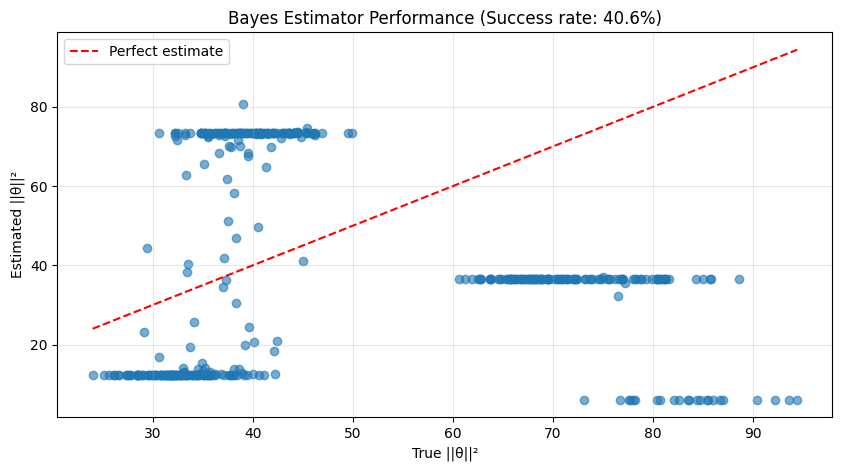

In [10]:
results = run_simulations(M=1000)

# Filter 1: Remove NaN values
valid_mask = ~np.isnan(results[:, 1])
valid_results = results[valid_mask]

# Filter 2: Remove negative estimates (impossible, since estimating ||θ||²)
positive_mask = valid_results[:, 1] > 0
valid_results = valid_results[positive_mask]

# Filter 3: Remove extreme percentage errors
# Keep only estimates within [-500%, +500%] relative error
true_vals = valid_results[:, 0]
est_vals = valid_results[:, 1]
percent_error = np.divide(
    100 * (est_vals - true_vals),
    true_vals,
    out=np.full_like(true_vals, np.nan, dtype=float),
    where=true_vals != 0,
 )
reasonable_error_mask = np.abs(percent_error) < 500
valid_results = valid_results[reasonable_error_mask]
percent_error = percent_error[reasonable_error_mask]

success_rate = len(valid_results) / len(results) * 100

print(f"Success rate (after outlier removal): {success_rate:.1f}% ({len(valid_results)}/{len(results)})")
print(f"\nValid estimates statistics:")
print(f"  Mean theta_sq: {np.mean(valid_results[:, 0]):.2f}")
print(f"  Mean estimate: {np.mean(valid_results[:, 1]):.2f}")
print(f"  Mean error: {np.mean(valid_results[:, 1] - valid_results[:, 0]):.2f}")
print(f"  MSE: {np.mean((valid_results[:, 1] - valid_results[:, 0])**2):.2f}")
print(f"  Mean |% error|: {np.mean(np.abs(percent_error)):.1f}%")

# Visualize
plt.figure(figsize=(10, 5))
plt.scatter(valid_results[:, 0], valid_results[:, 1], alpha=0.6)
plt.plot([valid_results[:, 0].min(), valid_results[:, 0].max()], 
         [valid_results[:, 0].min(), valid_results[:, 0].max()], 'r--', label='Perfect estimate')
plt.xlabel('True ||θ||²')
plt.ylabel('Estimated ||θ||²')
plt.title(f'Bayes Estimator Performance (Success rate: {success_rate:.1f}%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

As we can see, numerical techniques, at least naive integration with scipy, works extremely poorly. We don't even get a result most of the time, since the computation is so numerically unstable. It really is imperative to approach this from another method. Monte Carlo techniques are the only option.

# Monte Carlo

Instead of trying to compute the expectation, we can sample $\vartheta$ and compute the approximation to $\delta(x)$:
$$
\hat{\delta}(x) = \frac{\frac1{N}\sum_{i = 1}^N \frac{\vartheta_i}{2 \vartheta_i + p(\tau^{-2} + \sigma^{-2})}}{\frac1{N} \sum_{i = 1}^N \frac{\tau^{-2} + \sigma^{-2}}{2 \vartheta_i + p(\tau^{-2} + \sigma^{-2})}}
$$
where we sample $\theta_i \sim \chi_p^2(\lambda)$ as above. By (S/W)LLN and continuous mapping theorem, this will converge to $\delta^\ast(x)$. In fact, because we have access to the posterior of $\theta$, we can actually just sample $\theta$ and compute:
$$
\hat{\delta}(x) = \frac{\frac{1}{N} \sum_{i = 1}^N \frac{\|\theta_i\|^2}{2 \|\theta_i\|^2 + p}}{\frac1{N} \sum_{i = 1}^N \frac1{2\|\theta_i\|^2 + p}}
$$
This is already much easier to implement, and as we will see, significantly more numerically stable. 

Let's implement this!

In [ ]:
# first, we implement a single simulation. 
def mc_est_sim(M = 1000, p = 10, mu = np.ones(p), sigma = 2, tau = 2, N = 50):
    theta = rng.multivariate_normal(mean = mu, cov = tau **2 * np.eye(p))
    X = rng.multivariate_normal(mean = theta, cov = sigma **2 * np.eye(p), size = N)
    x_bar = np.mean(X, axis = 0)
    mu_post = (x_bar * tau ** 2 + mu * sigma ** 2 / N) / (tau ** 2 + sigma ** 2 / N)
    sigma_post_sq = (sigma ** 2 / N * tau ** 2) / (sigma ** 2 / N + tau ** 2)
    # Now we sample M times from the posterior distribution of theta:
    theta_x = rng.multivariate_normal(mean = mu_post, cov = sigma_post_sq * np.eye(p), size = M)
    theta_x_sq = np.sum(theta_x ** 2, axis = 1)
    num = np.sum(theta_x_sq / (2 * theta_x_sq + p * (1 / tau ** 2 + N / sigma ** 2))) 
    denom = np.sum(1 / (2 * theta_x_sq + p * (1 / tau ** 2 + N / sigma ** 2)))
    return {"theta_sq": np.sum(theta ** 2), "theta_sq_hat": num / denom}

In [ ]:
# let's redefine the run_simulations function to use the Monte Carlo Estimator
def run_simulations(method, num_sim = 100, p = 10, mu = np.ones(p), sigma = 2, tau = 2, N = 50, M = 1000):
    results = np.zeros((num_sim, 2))
    for i in range(num_sim):
        if method == "numerical":
             res = num_est_sim(p, mu, sigma, tau, N)
        if method == "monte_carlo":
             res = mc_est_sim(M=M, p=p, mu=mu, sigma=sigma, tau=tau, N=N)
        results[i] = [res["theta_sq"], res["theta_sq_hat"]]
    return results

In [8]:
# summarization of results utility
def summarize_results(results, method_name = "Bayes Estimator"):
    valid_mask = ~np.isnan(results[:, 1])
    valid_results = results[valid_mask]

    positive_mask = valid_results[:, 1] > 0
    valid_results = valid_results[positive_mask]

    true_vals = valid_results[:, 0]
    est_vals = valid_results[:, 1]
    percent_error = np.divide(
        100 * (est_vals - true_vals),
        true_vals,
        out=np.full_like(true_vals, np.nan, dtype=float),
        where=true_vals != 0,
    )
    reasonable_error_mask = np.abs(percent_error) < 500
    valid_results = valid_results[reasonable_error_mask]
    percent_error = percent_error[reasonable_error_mask]

    success_rate = len(valid_results) / len(results) * 100

    print(f"Success rate (after outlier removal): {success_rate:.1f}% ({len(valid_results)}/{len(results)})")
    print(f"\nValid estimates statistics:")
    print(f"  Mean theta_sq: {np.mean(valid_results[:, 0]):.2f}")
    print(f"  Mean estimate: {np.mean(valid_results[:, 1]):.2f}")
    print(f"  Mean error: {np.mean(valid_results[:, 1] - valid_results[:, 0]):.2f}")
    print(f"  MSE: {np.mean((valid_results[:, 1] - valid_results[:, 0])**2):.2f}")
    print(f"  Mean |% error|: {np.mean(np.abs(percent_error)):.1f}%")

    # Visualize
    plt.figure(figsize=(10, 5))
    plt.scatter(valid_results[:, 0], valid_results[:, 1], alpha=0.6)
    plt.plot([valid_results[:, 0].min(), valid_results[:, 0].max()], 
             [valid_results[:, 0].min(), valid_results[:, 0].max()], 'r--', label='Perfect estimate')
    plt.xlabel('True ||θ||²')
    plt.ylabel('Estimated ||θ||²')
    plt.title(f'{method_name} Performance (Success rate: {success_rate:.1f}%)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    plt.clf()

Success rate (after outlier removal): 100.0% (1000/1000)

Valid estimates statistics:
  Mean theta_sq: 50.17
  Mean estimate: 50.08
  Mean error: -0.09
  MSE: 14.99
  Mean |% error|: 6.9%


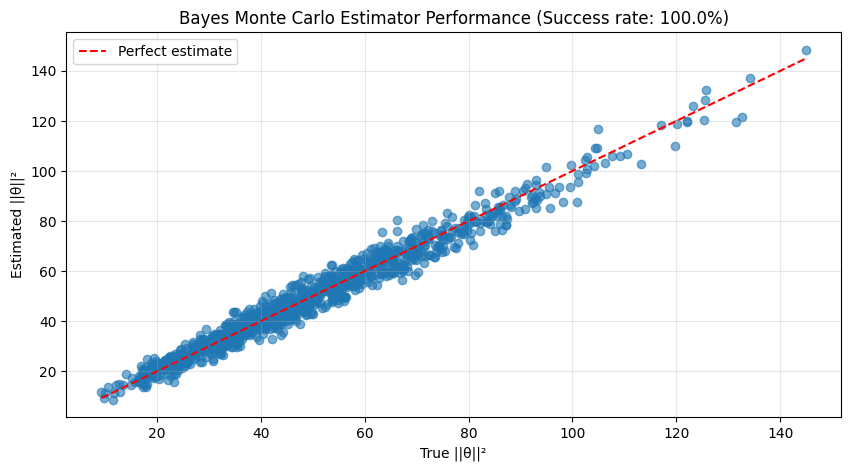

<Figure size 640x480 with 0 Axes>

In [ ]:
# let's run this simulation num_sim = 1000 times and compare the results to the numerical estimator.
num_sim = 1000
mc_res = run_simulations(method="monte_carlo", num_sim=num_sim)
summarize_results(mc_res, method_name = "Bayes Monte Carlo Estimator")

This is much much better! However, this is still a pretty easy problem. Our posterior distribution has a nice closed form, and the $\chi_p^2(\lambda)$ distribution is very easy to sample from. What happens if we have a distribution that is not very easy to sample from? We investigate this in the next part of this tutorial [Importance Sampling](is.ipynb)